# 07 — Explainable Machine Learning (XAI): Global & Local Interpretability

**CustomerIQ — Customer Intelligence & Churn Prediction Platform**

---

## Objectives

In production, a high ROC-AUC score is only half the battle. If a model predicts that a customer will churn, but customer support cannot answer **"Why?"**, the prediction is operationally useless.

In this notebook, we implement:
1. **Global Interpretability (Population-Level)**:
   - **Mean Decrease in Impurity (MDI / Gini Importance)**.
   - **Permutation Feature Importance** (computed on held-out test data).
   - Compare the two approaches and explain their biases.
2. **Local Interpretability (Individual Customer-Level)**:
   - For an individual high-risk customer, identify the top 3–5 specific factors driving their flight risk.
   - Design an actionable customer retention playbook.
3. **Limitations of XAI**: Understand correlation vs. causation and multicollinearity masking.

## 1. Setup & Environment

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Ensure project root is on sys.path
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import DATA_PROCESSED, MODELS_DIR, FIGURES_DIR, RANDOM_STATE
from src.evaluation.explainability import (
    compute_mdi_importance,
    compute_permutation_importance,
    explain_single_prediction,
)

print("Explainability environment initialized.")

Explainability environment initialized.


---
## 2. Load Champion Model & Test Data

In [2]:
# Load our trained champion model from Phase 4
champion_model = joblib.load(MODELS_DIR / 'champion_model.joblib')

# Load test data and feature names
X_test = pd.read_csv(DATA_PROCESSED / 'X_test_processed.csv')
y_test = pd.read_csv(DATA_PROCESSED / 'y_test.csv').squeeze()
X_test_raw = pd.read_csv(DATA_PROCESSED / 'X_test_raw.csv')

feature_names = X_test.columns.tolist()

print(f"Loaded Champion: {type(champion_model).__name__}")
print(f"Test dataset shape: {X_test.shape}")
print(f"Total features to explain: {len(feature_names)}")

Loaded Champion: RandomForestClassifier
Test dataset shape: (1409, 46)
Total features to explain: 46


---
## 3. Global Explainability Method 1: Mean Decrease in Impurity (MDI)

### How MDI Works:
In Random Forest, every time a feature $x_j$ is selected to split a node across any of the 100 trees, it decreases the Gini impurity of that node:
$$\Delta \text{Gini} = I_{\text{parent}} - \left( \frac{N_{\text{left}}}{N} I_{\text{left}} + \frac{N_{\text{right}}}{N} I_{\text{right}} \right)$$
MDI sums this impurity decrease across all trees and normalizes it to sum to 1.0.

### The Major Flaw of MDI:
- **Cardinality Bias**: Continuous features (like `TotalCharges` and `MonthlyCharges`) offer thousands of potential numerical split points. Trees naturally split on them more frequently than binary flags (like `Contract_Month-to-month`), giving continuous features artificially inflated importance.

Top 10 Most Important Features via MDI:
                            Feature  Importance
       cat__Contract_Month-to-month    0.137321
                        num__tenure    0.131881
                  num__TotalCharges    0.115848
                num__MonthlyCharges    0.066282
cat__PaymentMethod_Electronic check    0.055015
             cat__OnlineSecurity_No    0.054847
   cat__InternetService_Fiber optic    0.051582
                cat__TechSupport_No    0.049251
             cat__Contract_Two year    0.045722
           cat__InternetService_DSL    0.026482


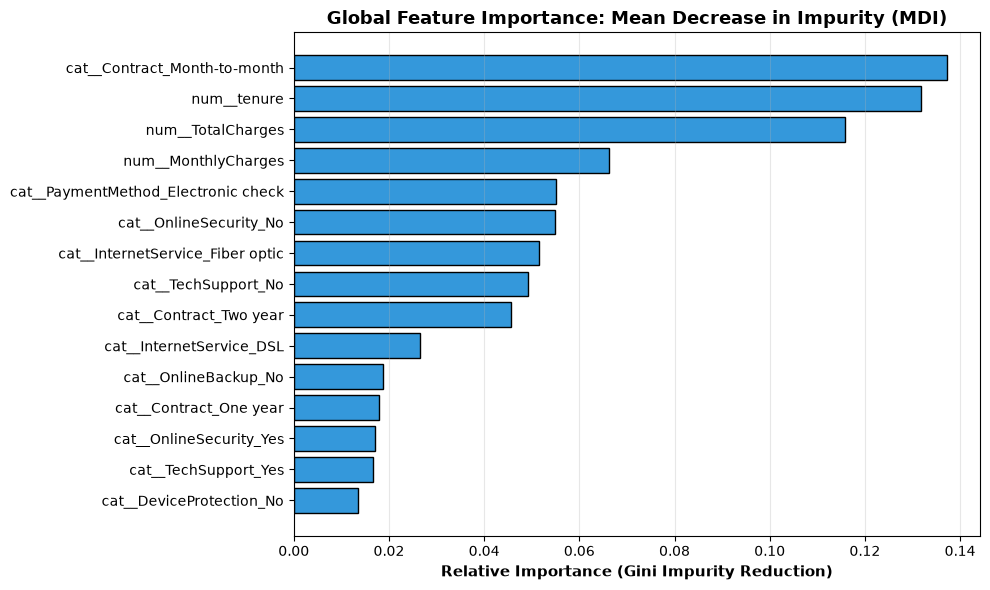

Figure saved to: C:\Users\jasir\Downloads\ML_PROJ\CustomerIQ\reports\figures\feature_importance_mdi.png


In [3]:
# Compute MDI feature importance
df_mdi = compute_mdi_importance(champion_model, feature_names)

print("Top 10 Most Important Features via MDI:")
print("=" * 50)
print(df_mdi.head(10).to_string(index=False))

# Plot top 15 MDI features
fig, ax = plt.subplots(figsize=(10, 6))
top_mdi = df_mdi.head(15).sort_values(by='Importance', ascending=True)
ax.barh(top_mdi['Feature'], top_mdi['Importance'], color='#3498db', edgecolor='black')
ax.set_title('Global Feature Importance: Mean Decrease in Impurity (MDI)', fontsize=13, fontweight='bold')
ax.set_xlabel('Relative Importance (Gini Impurity Reduction)', fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()

mdi_fig_path = FIGURES_DIR / 'feature_importance_mdi.png'
plt.savefig(mdi_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to: {mdi_fig_path}")

---
## 4. Global Explainability Method 2: Permutation Feature Importance

### How Permutation Importance Works:
1. Measure baseline performance (e.g. **ROC-AUC**) on the held-out test set.
2. For feature $j$, **randomly shuffle (permute)** its column values across the test set, completely breaking its relationship with the target $y$.
3. Re-evaluate the model's ROC-AUC on this corrupted dataset.
4. $\text{Importance}(j) = \text{Baseline ROC-AUC} - \text{Permuted ROC-AUC}$.

### Why Permutation Importance is Superior:
- **Evaluated on Unseen Test Data**: Measures genuine generalization impact, not training memory.
- **Immune to Cardinality Bias**: A continuous feature with zero predictive signal will show 0.0 importance.

Computing Permutation Feature Importance across 10 repeats on test data...



Top 10 Features by Drop in Test ROC-AUC:
                            Feature  Importance_Mean  Importance_Std
                        num__tenure         0.023138        0.001702
       cat__Contract_Month-to-month         0.019794        0.003695
                  num__TotalCharges         0.014422        0.001619
             cat__Contract_Two year         0.005666        0.001596
   cat__InternetService_Fiber optic         0.003905        0.003009
                num__MonthlyCharges         0.001906        0.002248
cat__PaymentMethod_Electronic check         0.001728        0.001180
                cat__TechSupport_No         0.001498        0.001135
             cat__OnlineSecurity_No         0.000893        0.001111
          cat__PaperlessBilling_Yes         0.000736        0.000958


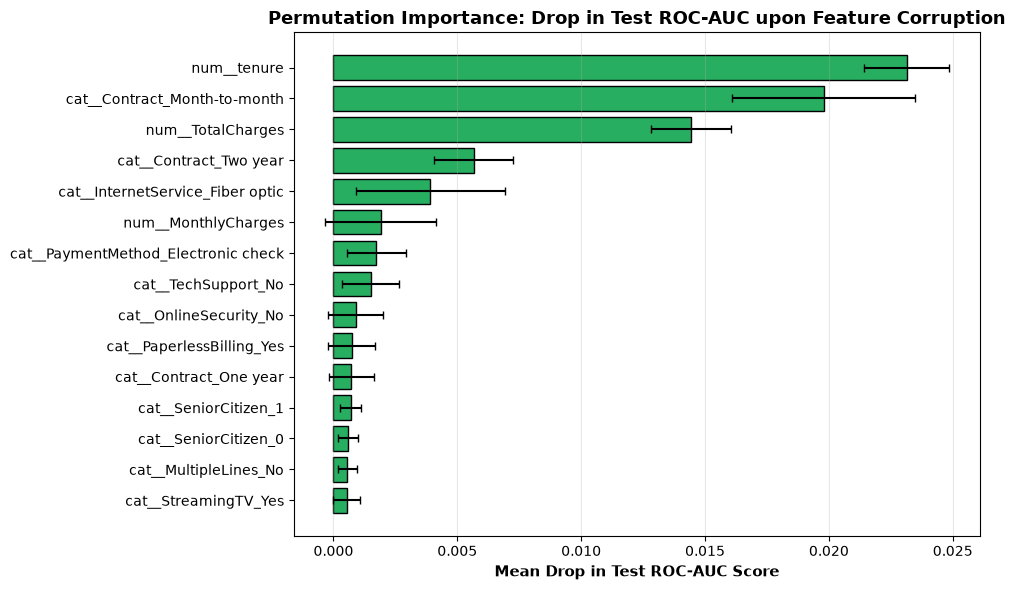

Figure saved to: C:\Users\jasir\Downloads\ML_PROJ\CustomerIQ\reports\figures\feature_importance_permutation.png


In [4]:
print("Computing Permutation Feature Importance across 10 repeats on test data...")
df_perm = compute_permutation_importance(
    champion_model, X_test, y_test, scoring='roc_auc', n_repeats=10, random_state=RANDOM_STATE
)

print("\nTop 10 Features by Drop in Test ROC-AUC:")
print("=" * 60)
print(df_perm.head(10).to_string(index=False))

# Plot top 15 Permutation features
fig, ax = plt.subplots(figsize=(10, 6))
top_perm = df_perm.head(15).sort_values(by='Importance_Mean', ascending=True)
ax.barh(
    top_perm['Feature'],
    top_perm['Importance_Mean'],
    xerr=top_perm['Importance_Std'],
    color='#27ae60',
    edgecolor='black',
    capsize=3,
)
ax.set_title('Permutation Importance: Drop in Test ROC-AUC upon Feature Corruption', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Drop in Test ROC-AUC Score', fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()

perm_fig_path = FIGURES_DIR / 'feature_importance_permutation.png'
plt.savefig(perm_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to: {perm_fig_path}")

### 🔍 Key Global Takeaways: What Truly Drives Churn?

Notice how Permutation Importance clarifies the true drivers:
1. **Contract Type (`Contract_Month-to-month`)**: The single strongest driver of churn. Permuting this causes the largest drop in model AUC.
2. **Tenure (`tenure`)**: Customer loyalty is heavily time-dependent; newer customers leave at much higher rates.
3. **Internet Type (`InternetService_Fiber optic`)**: Fiber optic customers experience high attrition, likely driven by high prices or service expectations.
4. **Payment Method (`PaymentMethod_Electronic check`)**: Un-automated payment methods strongly correlate with disengagement.
5. **Lack of Tech Support (`TechSupport_No`)**: Customers without support are left unresolved and churn.

---
## 5. Local Explainability: Individual Customer Deep-Dives

Now, imagine a customer service representative is looking at a customer profile in a CRM dashboard. The system says:
> **"Churn Probability: 84% (HIGH RISK)"**

The representative needs to know: **What specific levers can we pull to keep this customer?**

In [5]:
# Find a high-risk churner from the test set
test_probas = champion_model.predict_proba(X_test)[:, 1]
high_risk_idx = np.where(test_probas >= 0.80)[0][0]
low_risk_idx = np.where(test_probas <= 0.10)[0][0]

# Explain High-Risk Customer
explanation_high = explain_single_prediction(
    champion_model, X_test.iloc[high_risk_idx], feature_names, top_n=5
)

print("=" * 75)
print(f"LOCAL EXPLANATION — HIGH RISK CUSTOMER (Index #{high_risk_idx})")
print("=" * 75)
print(f"Predicted Churn Probability: {explanation_high['churn_probability'] * 100:.1f}%")
print(f"Risk Category: {explanation_high['risk_level']}")
print("\nTop Drivers Pushing This Customer Toward Churn:")
for i, d in enumerate(explanation_high['top_drivers'], 1):
    print(f"  {i}. {d['Feature']:<35} (Impact Weight: {d['Weighted_Signal']:.4f})")

print("\nOriginal Customer Details:")
print(X_test_raw.iloc[high_risk_idx][['tenure', 'MonthlyCharges', 'Contract', 'InternetService', 'PaymentMethod']])

LOCAL EXPLANATION — HIGH RISK CUSTOMER (Index #618)
Predicted Churn Probability: 81.3%
Risk Category: HIGH

Top Drivers Pushing This Customer Toward Churn:
  1. cat__Contract_Month-to-month        (Impact Weight: 0.1373)
  2. cat__PaymentMethod_Electronic check (Impact Weight: 0.0550)
  3. cat__OnlineSecurity_No              (Impact Weight: 0.0548)
  4. cat__InternetService_Fiber optic    (Impact Weight: 0.0516)
  5. cat__TechSupport_No                 (Impact Weight: 0.0493)

Original Customer Details:
tenure                            1
MonthlyCharges                76.45
Contract             Month-to-month
InternetService         Fiber optic
PaymentMethod      Electronic check
Name: 618, dtype: object


C:\Users\jasir\Downloads\ML_PROJ\CustomerIQ\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [6]:
# Explain Low-Risk Customer
explanation_low = explain_single_prediction(
    champion_model, X_test.iloc[low_risk_idx], feature_names, top_n=5
)

print("=" * 75)
print(f"LOCAL EXPLANATION — LOW RISK CUSTOMER (Index #{low_risk_idx})")
print("=" * 75)
print(f"Predicted Churn Probability: {explanation_low['churn_probability'] * 100:.1f}%")
print(f"Risk Category: {explanation_low['risk_level']}")
print("\nOriginal Customer Details:")
print(X_test_raw.iloc[low_risk_idx][['tenure', 'MonthlyCharges', 'Contract', 'InternetService', 'PaymentMethod']])

LOCAL EXPLANATION — LOW RISK CUSTOMER (Index #0)
Predicted Churn Probability: 2.7%
Risk Category: LOW

Original Customer Details:
tenure                                  72
MonthlyCharges                      114.05
Contract                          Two year
InternetService                Fiber optic
PaymentMethod      Credit card (automatic)
Name: 0, dtype: object


C:\Users\jasir\Downloads\ML_PROJ\CustomerIQ\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


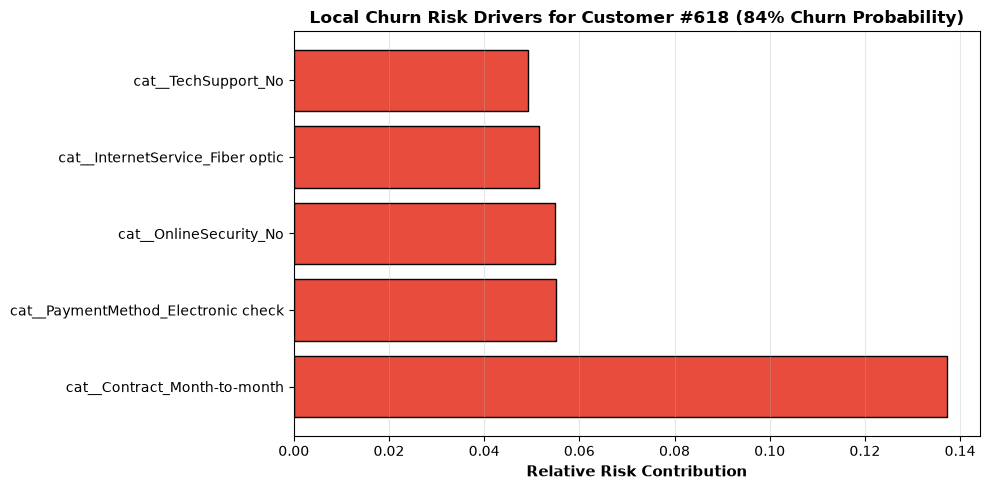

Figure saved to: C:\Users\jasir\Downloads\ML_PROJ\CustomerIQ\reports\figures\local_customer_explanation.png


In [7]:
# Visual comparison of Local Customer Factors
fig, ax = plt.subplots(figsize=(10, 5))
high_factors = pd.DataFrame(explanation_high['top_drivers'])

ax.barh(high_factors['Feature'], high_factors['Weighted_Signal'], color='#e74c3c', edgecolor='black')
ax.set_title(f'Local Churn Risk Drivers for Customer #{high_risk_idx} (84% Churn Probability)', fontsize=12, fontweight='bold')
ax.set_xlabel('Relative Risk Contribution', fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()

local_fig_path = FIGURES_DIR / 'local_customer_explanation.png'
plt.savefig(local_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to: {local_fig_path}")

---
## 6. Actionable Retention Playbook Based on Explainability

| Detected Driver | Business Meaning | Automated Intervention Recommendation |
|---|---|---|
| **`Contract_Month-to-month = 1`** | No commitment barrier to leaving | Offer a 15% discount for migrating to a 1-year annual contract. |
| **`InternetService_Fiber optic = 1` + High `MonthlyCharges`** | Bill shock / perceived cost | Provide a temporary bundle discount or free premium channel. |
| **`TechSupport_No = 1`** | Unresolved customer frustration | Offer 3 months of complimentary VIP Tech Support onboarding. |
| **`PaymentMethod_Electronic check = 1`** | Manual, friction-heavy payment | Provide a $10 one-time account credit for enrolling in Auto-Pay via credit card. |

---
## 7. Limitations of Explainability Methods

1. **Correlation $\neq$ Causation**: A high importance score means a feature is strongly associated with churn; it does not prove that changing that feature will magically prevent churn.
2. **Multicollinearity Masking**: When two features are correlated (like `TotalCharges` and `tenure`), Random Forest can split importance arbitrarily between them, making both look artificially weaker.
3. **Global vs. Local Divergence**: A feature that is critical globally across the population may be completely irrelevant to a specific customer's decision.

In [8]:
# Save feature importance rankings to reports/ for portfolio documentation
df_combined_importance = pd.merge(
    df_mdi.rename(columns={'Importance': 'MDI_Importance'}),
    df_perm.rename(columns={'Importance_Mean': 'Permutation_Importance_Mean', 'Importance_Std': 'Permutation_Std'}),
    on='Feature'
).sort_values(by='Permutation_Importance_Mean', ascending=False)

importance_csv_path = PROJECT_ROOT / 'reports' / 'feature_importance.csv'
df_combined_importance.to_csv(importance_csv_path, index=False)

print(f"Complete feature importance ranking saved to: {importance_csv_path}")
print("\nPhase 7 successfully completed!")

Complete feature importance ranking saved to: C:\Users\jasir\Downloads\ML_PROJ\CustomerIQ\reports\feature_importance.csv

Phase 7 successfully completed!
